# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


Epoch [1/20], Loss: 0.6887, 학습 정확도: 68.48%, 평가 정확도: 70.15%
Epoch [2/20], Loss: 0.6517, 학습 정확도: 70.41%, 평가 정확도: 70.08%
Epoch [3/20], Loss: 0.6425, 학습 정확도: 70.72%, 평가 정확도: 70.37%
Epoch [4/20], Loss: 0.6360, 학습 정확도: 70.91%, 평가 정확도: 70.61%
Epoch [5/20], Loss: 0.6312, 학습 정확도: 71.15%, 평가 정확도: 70.52%
Epoch [6/20], Loss: 0.6271, 학습 정확도: 71.27%, 평가 정확도: 70.85%
Epoch [7/20], Loss: 0.6229, 학습 정확도: 71.56%, 평가 정확도: 70.84%
Epoch [8/20], Loss: 0.6197, 학습 정확도: 71.65%, 평가 정확도: 71.11%
Epoch [9/20], Loss: 0.6161, 학습 정확도: 71.76%, 평가 정확도: 71.19%
Epoch [10/20], Loss: 0.6141, 학습 정확도: 71.83%, 평가 정확도: 70.60%
Epoch [11/20], Loss: 0.6110, 학습 정확도: 72.04%, 평가 정확도: 70.80%
Epoch [12/20], Loss: 0.6093, 학습 정확도: 72.03%, 평가 정확도: 71.48%
Epoch [13/20], Loss: 0.6070, 학습 정확도: 72.15%, 평가 정확도: 71.33%
Epoch [14/20], Loss: 0.6050, 학습 정확도: 72.27%, 평가 정확도: 71.45%
Epoch [15/20], Loss: 0.6028, 학습 정확도: 72.39%, 평가 정확도: 70.84%
Epoch [16/20], Loss: 0.6011, 학습 정확도: 72.44%, 평가 정확도: 71.67%
Epoch [17/20], Loss: 0.5987, 학습 정확도: 72.57%, 평가 정

### 주제: 금융 행동 패턴 분석을 통한 신용 등급 분류 모델

# 최종 모델 완성 및 결과값

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import random

# 시드 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


# 데이터 로드 및 전처리
print("데이터 전처리 시작...")

data = pd.read_csv('train2.csv')

# 불필요 식별자 제거를 제거하여 학습에 필요한 변수만 사용
drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month']
data = data.drop(columns=drop_cols)


# 수치형 변수 추출
num_features = data.select_dtypes(include=[np.number]).columns.tolist()

if 'Credit_Score' in num_features:
    num_features.remove('Credit_Score')

# 음수값 처리
# 실제로 음수가 비정상인 변수만 선택
# -> 음수값을 중앙값으로 대체

# 음수가 불가능한 변수에 대해 음수값 존재 여부를 사전 확인
# → EDA 결과 해당 변수에 음수값 없음을 확인, 코드는 방어적 처리로 유지
# 결측치 없음을 EDA에서 확인하였으나, 추후 데이터 변동에 대비해 전처리 구조 유지

negative_invalid_cols = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in negative_invalid_cols:
    if col in data.columns:
        data.loc[data[col] < 0, col] = data[col].median()

# 이상치 clipping
# 상위 1% 극단값 제한
for col in num_features:
    upper_limit = data[col].quantile(0.99)
    data[col] = data[col].clip(upper=upper_limit)

# Credit_Mix 순서형 인코딩
# Good > Standard > Bad 순서 반영
data['Credit_Mix'] = data['Credit_Mix'].map({
    'Good': 2,
    'Standard': 1,
    'Bad': 0
}).fillna(1)


# Type_of_Loan 파생변수 생성
# 대출 종류 개수 사용
data['Type_of_Loan'] = (
    data['Type_of_Loan']
    .astype(str)
    .apply(lambda x: len(x.split(',')) if x != 'nan' else 0)
)

# 범주형 변수 One-Hot Encoding
data = pd.get_dummies(
    data,
    columns=[
        'Occupation',
        'Payment_Behaviour',
        'Payment_of_Min_Amount'
    ]
)

# 타겟 인코딩
target_map = {
    'Good': 0,
    'Standard': 1,
    'Poor': 2
}

data['Credit_Score'] = data['Credit_Score'].map(target_map)

# 전처리 총 정리
# 신용 등급 예측과 무관한 불필요한 식별자 제거 (ID, Customer_ID, Name, SSN, Month)
# Month는 시계열 특성을 활용하지 않으므로 제거

# 음수가 불가능한 변수에 대해 음수값 존재 여부를 사전 확인
# → EDA 결과 해당 변수에 음수값 없음을 확인, 코드는 방어적 처리로 유지
# 결측치 없음을 EDA에서 확인하였으나, 추후 데이터 변동에 대비해 전처리 구조 유지

# 극단값이 모델 학습에 미치는 영향을 제한하기 위해서 이상치 클러핑

# Credit_Mix 순서형 인코딩 (Good=2, Standard=1, Bad=0)
# 명목형이 아닌 순서형 변수이므로 one-hot 대신 ordinal 인코딩

# 대출 종류 개수로 변환 (Type of loan) : 문자열 정보를 콤마 구분 개수로 수치화

# 순서 관계 없는 명목형 변수에 one-hot encoding 적용



# 학습 / 검증 데이터 분리
# 클래스 비율 차이 확인 후 stratify 적용으로 클래스 비율 유지
X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
) # 8:2 validation

# # 데이터 스케일링
# 이상치 영향을 줄이기 위해 RobustScaler 사용
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Tensor 변환
# PyTorch 학습용 TensorDataset 생성
train_dataset = TensorDataset(
    torch.FloatTensor(X_train),
    torch.LongTensor(y_train)
)

val_dataset = TensorDataset(
    torch.FloatTensor(X_val),
    torch.LongTensor(y_val)
)

# DataLoader 구성
# mini-batch 학습 적용
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

# DNN 모델 정의
class CreditScoreModel(nn.Module):

    def __init__(self, input_dim):
        super(CreditScoreModel, self).__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 512), # Input Layer
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256), # Hidden Layer
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128), # Hidden Layer
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Output Layer
            # 3-class classification
            nn.Linear(128, 3)
        )

        self._init_weights()

    # He Initialization 적용
    def _init_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Linear):

                nn.init.kaiming_normal_(
                    m.weight,
                    nonlinearity='relu'
                )

                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    # Forward propagation
    def forward(self, x):
        return self.net(x)


# Device 설정
# GPU 사용 가능 시 CUDA 사용
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# 모델 생성
model = CreditScoreModel(
    X_train.shape[1]
).to(device)

# Loss Function 정의
# 다중 분류 문제이므로 CrossEntropyLoss 사용
criterion = nn.CrossEntropyLoss()

# Optimizer 설정
# Adam Optimizer + Weight Decay 적용
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

# Learning Rate Scheduler 설정
# CosineAnnealingLR 적용
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

# Early Stopping 설정
# Validation Accuracy 기준 저장
patience = 10

best_acc = 0
early_stop_counter = 0

num_epochs = 100


# Feature Selection
# 개인 식별자 제거로 불필요 변수 배제
# 순서형 인코딩을 통해 정보 손실 최소화 (Credit_mix)
# 문자열을 수치로 변환해 모델 입력 가능하게 변환 (Type_of_Loan)
# one-hot으로 범주 간 독립성 보장

# 모델 선택
# 다수의 수치형 + 범주형 혼합 피처를 비선형 관계로 학습 가능
# 3-class 분류 → 출력층 노드 수 3, CrossEntropyLoss 적용
# 구조: 512 → 256 → 128 → 3
# He Initialization: ReLU 활성화 함수에 최적화된 초기화 방식
# BatchNorm: 학습 안정화 및 수렴 속도 향상
# Dropout(0.3/0.2): 과적합 방지

# DNN 선정 이유
# : 본 데이터는 수치형 변수와 인코딩된 범주형 변수가 혼합됨
# 구차원 구조로 변수 간 비선형 관계 존재할 가능성이 높다고 판단함 -> DNN이 표현력 측면에서 유리하다고 판단하여 사용


# 튜닝 기준
# Optimizer: Adam (lr=0.001, weight_decay=1e-5) → weight decay로 L2 정규화 효과 부여
# Scheduler: CosineAnnealingLR (T_max=10) → 학습률을 점진적으로 감소시켜 안정적 수렴 유도
# Early Stopping: patience=10, validation accuracy 기준 → 과적합 시점에서 자동 종료 및 최적 모델 저장
# Batch size: 256, Epoch: 최대 100

# 학습 시작

print("학습 시작... (5 epoch마다 결과 출력)")

for epoch in range(num_epochs):

    # Train
    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad() # Gradient 초기화

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch) # Loss 계산

        loss.backward()

        optimizer.step()  # 가중치 update

        train_loss += loss.item()

    # validation
    model.eval()

    val_loss = 0.0

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1) # 예측 클래스 추출

            total += y_batch.size(0)

            correct += (predicted == y_batch).sum().item()

    # 평균 Loss 계산
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    # Validation Accuracy 계산
    val_acc = (correct / total) * 100

    # 결과 출력
    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f'Epoch [{epoch+1}/{num_epochs}] '
            f'Train Loss: {avg_train_loss:.4f} | '
            f'Val Loss: {avg_val_loss:.4f} | '
            f'Val Acc: {val_acc:.2f}%'
        )

    # Learning Rate Scheduler 적용
    scheduler.step()

    # 모델 저장 기준 수정
    # Validation Accuracy 기준 저장
    if val_acc > best_acc:

        best_acc = val_acc

        early_stop_counter = 0

        torch.save(
            model.state_dict(),
            'best_credit_model.pth'
        )

    else:
        early_stop_counter += 1

    # 조기종료
    if early_stop_counter >= patience:

        print(
            f'\n[{epoch+1} Epoch] 조기 종료 발생'
        )

        print(
            f'Best Validation Accuracy: '
            f'{best_acc:.2f}%'
        )

        break

# 최고 성능 모델 불러오기
model.load_state_dict(
    torch.load('best_credit_model.pth')
)

print("\n최고 성능 모델 로드 완료")
print(f"Best Validation Accuracy: {best_acc:.2f}%")

데이터 전처리 시작...
학습 시작... (5 epoch마다 결과 출력)
Epoch [1/100] Train Loss: 0.7322 | Val Loss: 0.6795 | Val Acc: 69.45%
Epoch [5/100] Train Loss: 0.6568 | Val Loss: 0.6524 | Val Acc: 71.13%
Epoch [10/100] Train Loss: 0.6391 | Val Loss: 0.6441 | Val Acc: 71.52%
Epoch [15/100] Train Loss: 0.6404 | Val Loss: 0.6427 | Val Acc: 71.56%
Epoch [20/100] Train Loss: 0.6291 | Val Loss: 0.6343 | Val Acc: 72.29%
Epoch [25/100] Train Loss: 0.5999 | Val Loss: 0.6121 | Val Acc: 73.33%
Epoch [30/100] Train Loss: 0.5730 | Val Loss: 0.5957 | Val Acc: 74.27%
Epoch [35/100] Train Loss: 0.5745 | Val Loss: 0.5916 | Val Acc: 74.64%
Epoch [40/100] Train Loss: 0.5727 | Val Loss: 0.5878 | Val Acc: 75.11%
Epoch [45/100] Train Loss: 0.5438 | Val Loss: 0.5661 | Val Acc: 76.05%
Epoch [50/100] Train Loss: 0.5122 | Val Loss: 0.5508 | Val Acc: 77.00%
Epoch [55/100] Train Loss: 0.5175 | Val Loss: 0.5474 | Val Acc: 77.14%
Epoch [60/100] Train Loss: 0.5242 | Val Loss: 0.5481 | Val Acc: 77.13%
Epoch [65/100] Train Loss: 0.4987 | Va

In [ ]:
# 매 epoch마다 Train Loss, Val Loss, Val Accuracy를 계산
# 5 epoch 주기로 출력하여 학습 추이 모니터링
# - Best Validation Accuracy: 79.65%

In [ ]:
# 개선사항

# 1. Feature Selection 정량화 미적용
# - 제거된 변수는 도메인 기반 수동 선택
# - Feature Importance, SHAP, 상관계수 기반 정량적 선택 기법 도입 고려

# 2. 클래스 불균형 처리 심화
# - stratify로 비율 유지하였으나, 클래스 가중치 또는 오버샘플링(SMOTE) 적용으로 소수 클래스 학습 강화 가능

# 3. 앙상블 미적용
# - DNN 단일 모델만 사용
# - 트리 기반 모델과 앙상블 사용 시 향상 가능할 것으로 예측

# 4. 이상치 하한 처리 미흡
# - 상위 1%만 이상치 클리핑 적용
# - 하위 이상치도 quantile(0.01) 기준으로 대칭 처리 검토

# 5. 하이퍼파라미터 탐색 미적용
# - optuna 기반 자동 탐색으로 최적화 가능

# 시각화

In [ ]:
# EDA를 통한 타당한 해석

# 1. 수치형 변수 분포 확인
# - 분포 및 이상치 존재 여부를 파악한 뒤 클러핑 적용

# 2. 음수가 불가능한 변수에 대해 음수값 존재 여부를 사전 확인
# -  EDA 결과 해당 변수에 음수값 없음을 확인, 코드는 방어적 처리로 유지
# - 결측치 없음을 EDA에서 확인하였으나, 추후 데이터 변동에 대비해 전처리 구조 유지

# 3. 수치형 변수 전반에 상위 극단값이 확인되었으므로 quantitle(0.99) 기준으로 클리핑 적용

# 4. 'Good', 'Standard', 'Bad' 3단계 순서형 변수임을 확인하고 ordinal encoding (2/1/0) 적용

# 5. type of loan의 문자열 구조 확인
# - 콤마로 구분된 형태를 확인했고 대출 종류 개수를 수치로 변환

# 6. 타겟 클래스 분포를 확인했고 stratify=y 적용으로 클래스 불균형 보정

In [ ]:
print("데이터 로드 중...")
data = pd.read_csv('train2.csv')
print(f"데이터 shape: {data.shape}")
print(f"\n결측치 상위 10개:\n{data.isnull().sum().sort_values(ascending=False).head(10)}")
print(f"\n타겟 분포:\n{data['Credit_Score'].value_counts()}")

데이터 로드 중...
데이터 shape: (100000, 28)

결측치 상위 10개:
ID                       0
Customer_ID              0
Month                    0
Name                     0
Age                      0
SSN                      0
Occupation               0
Annual_Income            0
Monthly_Inhand_Salary    0
Num_Bank_Accounts        0
dtype: int64

타겟 분포:
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


In [ ]:
# =========================================================
# 한글 폰트 설치
# =========================================================
!apt-get update -qq
!apt-get install fonts-nanum -qq

# =========================================================
# matplotlib 설정
# =========================================================
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 재설정
fm._load_fontmanager(try_read_cache=False)

# 사용 가능한 폰트 확인
font_list = [f.name for f in fm.fontManager.ttflist]

# NanumGothic 존재 확인
print('NanumGothic' in font_list)

# 한글 폰트 적용
matplotlib.rc('font', family='NanumGothic')

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
True


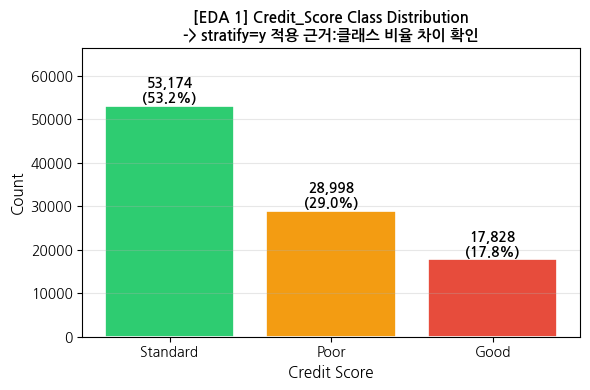

저장 완료: eda_01_target_distribution.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
data = pd.read_csv('train2.csv')
# 타겟 변수 클래스 분포
# → train_test_split에 stratify=y 적용 근거
fig, ax = plt.subplots(figsize=(6, 4))

target_counts = data['Credit_Score'].value_counts()
bar_colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(target_counts.index, target_counts.values,
              color=bar_colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{val:,}\n({val/len(data)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('[EDA 1] Credit_Score Class Distribution\n'
             '-> stratify=y 적용 근거:클래스 비율 차이 확인',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Credit Score', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_ylim(0, target_counts.max() * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: eda_01_target_distribution.png")

In [ ]:
# Standard 클래스 비율이 가장 높고, Good 클래스 비율이 가장 낮은 불균형 데이터 형태
# 클래스 비율 차이가 존재하므로 train_test_split 과정에서 stratify=y 적용

In [ ]:
# EDA 2. 음수값 발생 건수 확인

negative_invalid_cols = [
    'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]
valid_neg_cols = [c for c in negative_invalid_cols if c in data.columns]

neg_counts = {}
for col in valid_neg_cols:
    numeric_col = pd.to_numeric(data[col], errors='coerce')
    neg_counts[col] = int((numeric_col < 0).sum())

neg_series = pd.Series(neg_counts).sort_values(ascending=False)
neg_series = neg_series[neg_series > 0]

if len(neg_series) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(neg_series) * 0.5)))
    bars = ax.barh(neg_series.index, neg_series.values,
                   color='#e74c3c', alpha=0.8, edgecolor='white')

    for bar, val in zip(bars, neg_series.values):
        ax.text(bar.get_width() + max(neg_series.values) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9)

    ax.set_title('[EDA 2] Negative Value Count\n'
                 '-> 음수값 실제 존재 확인: median 대체 처리 근거',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Count', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('eda_02_negative_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장 완료: eda_02_negative_values.png")
else:
    print("[EDA 2] 해당 변수에 음수값 없음 - 그래프 생략")

#

[EDA 2] 해당 변수에 음수값 없음 - 그래프 생략


In [ ]:
# 음수가 불가능한 변수에 대해 음수값 존재 여부를 사전 확인
# → EDA 결과 해당 변수에 음수값 없음을 확인, 코드는 방어적 처리로 유지
# 결측치 없음을 EDA에서 확인하였으나, 추후 데이터 변동에 대비해 전처리 구조 유지

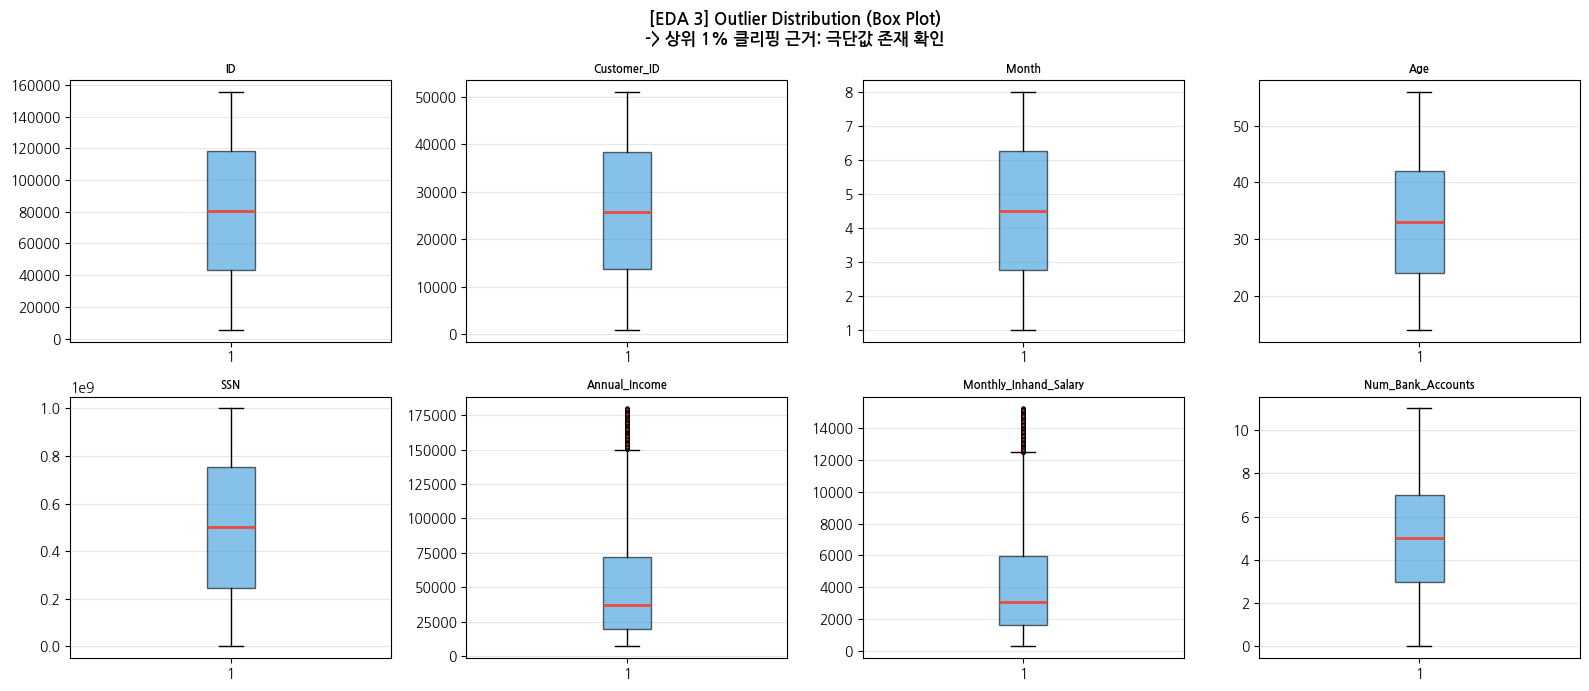

저장 완료: eda_03_boxplot_outliers.png


In [ ]:
# EDA 3. 수치형 변수 Box Plot (이상치 분포 확인) → 상위 1% 클리핑 근거: 극단값(outlier) 존재 여부

num_features = data.select_dtypes(include=[np.number]).columns.tolist()
if 'Credit_Score' in num_features:
    num_features.remove('Credit_Score')

plot_cols = num_features[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    numeric_col = pd.to_numeric(data[col], errors='coerce').dropna()
    axes[i].boxplot(
        numeric_col, vert=True, patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.6),
        medianprops=dict(color='#e74c3c', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                        markersize=2, alpha=0.3)
    )
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('[EDA 3] Outlier Distribution (Box Plot)\n'
             '-> 상위 1% 클리핑 근거: 극단값 존재 확인',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: eda_03_boxplot_outliers.png")


In [ ]:
# 일부 수치형 변수에서 극단값이 다수 존재함을 확인

# 특히 Annual_Income과 Monthly_Inhand_Salary 변수에서 상위 극단값이 관찰

# 극단값은 모델 학습 안정성을 저하시킬 수 있어 상위 1% clipping을 적용

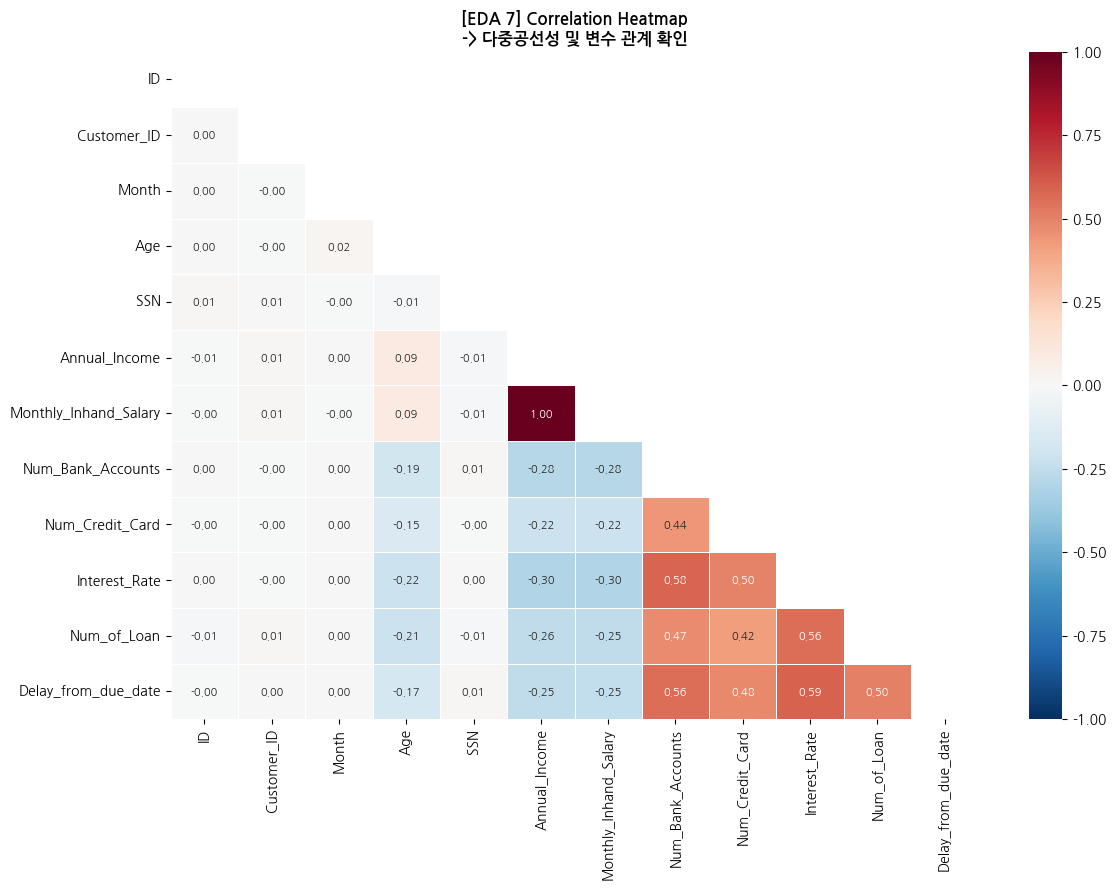

저장 완료: eda_07_correlation_heatmap.png


In [ ]:
#  수치형 변수 상관관계 히트맵 → 변수 간 다중공선성 및 관계 구조 확인

numeric_data = data[num_features].copy()
for col in numeric_data.columns:
    numeric_data[col] = pd.to_numeric(numeric_data[col], errors='coerce')

corr_cols = num_features[:12]
corr_matrix = numeric_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('[EDA 7] Correlation Heatmap\n'
             '-> 다중공선성 및 변수 관계 확인',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: eda_07_correlation_heatmap.png")


In [ ]:
# Annual_Income과 Monthly_Inhand_Salary는 매우 높은 양의 상관관계
# - 월급과 연소득이 직접적으로 연결된 변수이기 때문으로 해석

# Interest_Rate, Num_of_Loan, Delay_from_due_date 변수 간 양의 상관관계.
# - 대출 수와 연체 기록이 증가할수록 금리 수준도 함께 증가하는 경향